<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.2-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl (10.0 MB)
Using cached numpy-2.5.2-cp314-cp314-win_amd64.whl (12.6 MB)
Using cached tzdata-2026.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head(10)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
5,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
6,7,"I am not primarily a developer, but I write co...",35-44 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
7,8,I am learning to code,18-24 years old,"Student, full-time;Not employed, but looking f...",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Video-based Online Cou...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Difficult,NaN,NaN
8,9,I code primarily as a hobby,45-54 years old,"Employed, full-time",In-person,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Written-based Online Courses,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN
9,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [3]:
# Let's check the distribution of Industry column
industry_counts = df["Industry"].value_counts()
print(industry_counts)

# And missing values
missing_values = df["Industry"].isnull().sum()
print(f"Missing Industry values:", df["Industry"].isna().sum())

Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Higher Education                                890
Transportation, or Supply Chain                 859
Computer Systems Design and Services            844
Energy                                          578
Insurance                                       389
Name: count, dtype: int64
Missing Industry values: 36579


In [4]:
# Let's check the distribution in percentages %
industry_pct = (
    df["Industry"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

industry_pct

Industry
Software Development                          41.30
Other:                                        10.66
Fintech                                        5.69
Internet, Telecomm or Information Services     5.64
Banking/Financial Services                     4.75
Healthcare                                     4.43
Manufacturing                                  4.38
Retail and Consumer Services                   4.38
Government                                     3.33
Media & Advertising Services                   3.10
Higher Education                               3.08
Transportation, or Supply Chain                2.98
Computer Systems Design and Services           2.92
Energy                                         2.00
Insurance                                      1.35
Name: proportion, dtype: float64

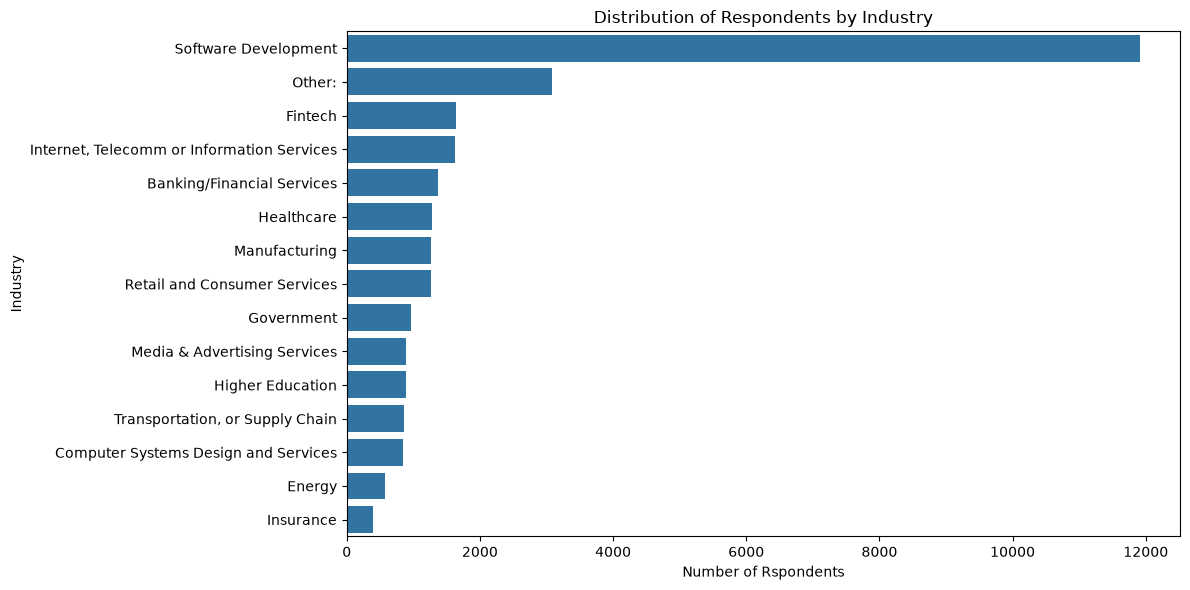

In [5]:
# Create a bar chart to visualize the distribution of respondents by Industry
plt.figure(figsize=(12,6))

sns.barplot(
    x=industry_counts.values,
    y=industry_counts.index
)

plt.title("Distribution of Respondents by Industry")
plt.xlabel("Number of Rspondents")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

**Conclusion:** The distribution shows that respondents are concentrated in a small number of industries, with the most represented industry **Software Development** for the largest share of participants. Other industries have considerably fewer respondents, indicating that the dataset is not evenly distributed across industries.

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [6]:
# Checking `ConvertedCompYearly` column
df["ConvertedCompYearly"].info()

<class 'pandas.Series'>
RangeIndex: 65437 entries, 0 to 65436
Series name: ConvertedCompYearly
Non-Null Count  Dtype  
--------------  -----  
23435 non-null  float64
dtypes: float64(1)
memory usage: 511.4 KB


In [7]:
# let's see how many values are missing
missing_values = df["ConvertedCompYearly"].isna().sum()
print(f"Missing values: {missing_values}")

Missing values: 42002


In [8]:
# For outliers detection we don't need to imput missing compensation values, we just need to exclude them for the analysis
compensation = df["ConvertedCompYearly"].dropna()

# Let's calculate the mean, median and std_comp
mean_comp = compensation.mean()
median_comp = compensation.median()
std_comp = compensation.std()

# We could use describe
# df["ConvertedCompYearly"].describe()
# but calculation make it easier for use each of them in the formula

print(f"Mean of ConvertedCompYearly: {mean_comp}")
print(f"Median of ConvertedCompYearly: {median_comp}")
print(f"Standard Deviation of ConvertedCompYearly: {std_comp}")

Mean of ConvertedCompYearly: 86155.28726264134
Median of ConvertedCompYearly: 65000.0
Standard Deviation of ConvertedCompYearly: 186756.97308629754


In [12]:
# Calculate the 3-stand-deviation threshold
threshold = mean_comp + (3 * std_comp)

print(f"Outlier threshold: ${threshold:,.2f}")

Outlier threshold: $646,426.21

Any yearly compensation greater then this threshold will be considered an extremely high compensation value

In [21]:
# Identifying the outliers
high_compensation = (
    df[df["ConvertedCompYearly"] > threshold]
    .sort_values(by="ConvertedCompYearly", ascending=False)
    .copy()
)

high_compensation

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
15837,15838,I am a developer by profession,25-34 years old,"Independent contractor, freelancer, or self-em...",In-person,Apples,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,16256603.0,NaN
12723,12724,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...","Hybrid (some remote, some in-person)",Apples,Contribute to open-source projects;Professiona...,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;On the job training;Oth...,Blogs;Stack Overflow;Coding sessions (live or ...,...,100.0,100.0,100.0,100.0,100.0,100.0,Appropriate in length,Neither easy nor difficult,13818022.0,10.0
28379,28380,I am a developer by profession,18-24 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Contribute to open-source projects,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;On the job training;Oth...,Technical documentation;Blogs;Books;Written Tu...,...,100.0,100.0,100.0,100.0,100.0,100.0,Appropriate in length,Neither easy nor difficult,9000000.0,10.0
17593,17594,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;On the job training;Oth...,Technical documentation;Books;Written Tutorial...,...,75.0,40.0,30.0,40.0,30.0,70.0,Appropriate in length,Easy,6340564.0,6.0
17672,17673,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Apples,Hobby;School or academic work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Stack Overflow;V...,...,25.0,35.0,20.0,10.0,0.0,0.0,Too long,Neither easy nor difficult,4936778.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13336,13337,"I am not primarily a developer, but I write co...",25-34 years old,"Employed, part-time","Hybrid (some remote, some in-person)",Apples,Freelance/contract work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Books / Physical media;School (i.e., Universit...",NaN,...,70.0,75.0,65.0,90.0,80.0,90.0,Appropriate in length,Easy,660660.0,7.0
6735,6736,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,I don’t code outside of work,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Blogs;Books;AI,...,0.0,0.0,0.0,0.0,0.0,0.0,Too long,NaN,650000.0,8.0
529,530,I am a developer by profession,25-34 years old,"Employed, full-time",In-person,Apples,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Books / Physical media;School (i.e., Universit...",NaN,...,40.0,20.0,0.0,30.0,10.0,0.0,Appropriate in length,Easy,650000.0,6.0
28381,28382,I am a developer by profession,25-34 years old,"Employed, full-time",In-person,Apples,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Other online resources ...,Technical documentation;Written Tutorials;Stac...,...,10.0,10.0,0.0,24.0,10.0,9.0,Too long,Easy,650000.0,7.0


In [22]:
# Count the number of outliers
print(f"Number of high compensation outliers:", len(high_compensation))

Number of high compensation outliers: 89

**Conclusion:** The mean, median, and standard deviation of ConvertedCompYearly were calculated after excluding missing values. Respondents with compensation greater than three standard deviations above the mean were identified as high-compensation outliers. Because compensation data can be highly skewed, these observations should be investigated further rather than automatically removed

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [24]:
# Let's calculate the Interquartile Range
Q1 = compensation.quantile(0.25)
Q3 = compensation.quantile(0.75)

# The IQR represents the range containing the middle 50% of compensation values
IQR = Q3 - Q1

print(f"Q1: ${Q1:,.2f}")
print(f"Q3: ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")

Q1: $32,712.00
Q3: $107,971.50
IQR: $75,259.50

In [27]:
# Determining the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")

# Below lower_bound - potential low outlier
# Above upper_bound - potential high outlier

Lower bound: $-80,177.25
Upper bound: $220,860.75

In [28]:
# Identifying outliers
outliers = df[
    (df["ConvertedCompYearly"] < lower_bound) |
    (df["ConvertedCompYearly"] > upper_bound)
].copy()

display(outliers[["ConvertedCompYearly"]].sort_values(
    "ConvertedCompYearly"
))

,ConvertedCompYearly
38188,221000.0
8418,221713.0
39168,221746.0
39997,222000.0
36158,222000.0
...,...
17672,4936778.0
17593,6340564.0
28379,9000000.0
12723,13818022.0


In [29]:
# Counting outliers
print("Number of outliers:", len(outliers))

Number of outliers: 978

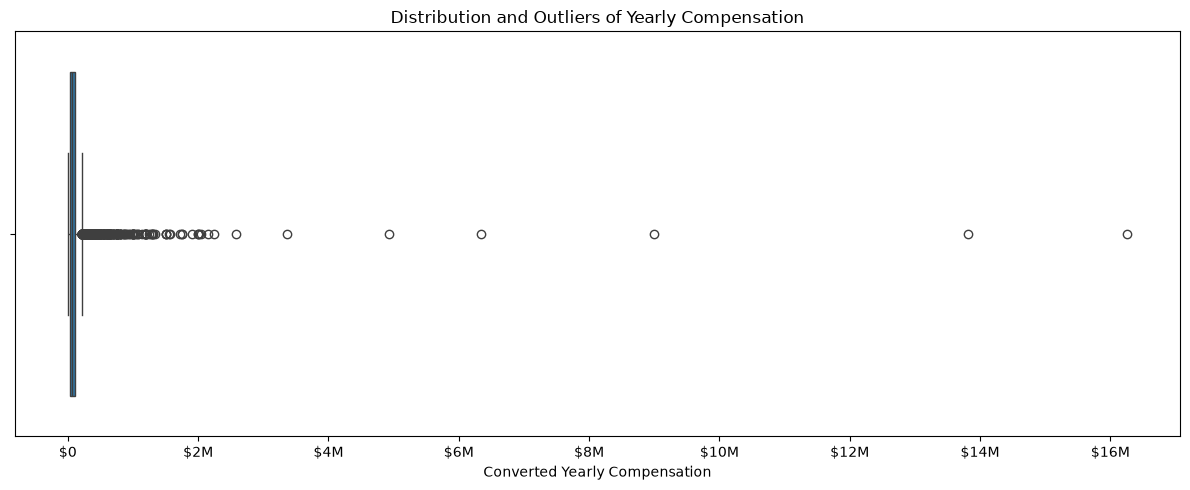

In [40]:
# Visualizing outliers using boxplot also called box and whiskers
# using tickers to format compensation as monetary values
from matplotlib.ticker import FuncFormatter

# Function to format the x labels like 30k 100k 500k 1M 15M values
def currency_formatter(x, pos):
    if x >= 1_000_000:
        return f"${x/1_000_000:.0f}M"
    elif x >= 1_000:
        return f"${x/1_000:.0f}K"
    else:
        return f"${x:.0f}"

plt.figure(figsize=(12, 5))

sns.boxplot(
    x=df["ConvertedCompYearly"]
)

plt.title("Distribution and Outliers of Yearly Compensation")
plt.xlabel("Converted Yearly Compensation")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.tight_layout()
plt.show()

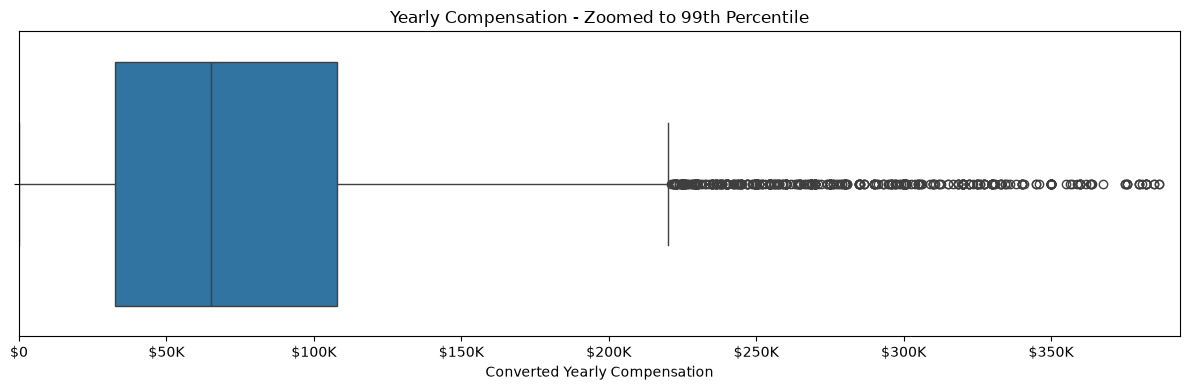

In [39]:
# Let's generate other boxplot zoomed
upper_limit = df["ConvertedCompYearly"].quantile(0.99)

plt.figure(figsize=(12, 4))

sns.boxplot(
    x=df["ConvertedCompYearly"]
)

plt.xlim(0, upper_limit)

plt.title("Yearly Compensation - Zoomed to 99th Percentile")
plt.xlabel("Converted Yearly Compensation")

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(currency_formatter)
)

plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [41]:
# Creating a new dataset without outliers
df_clean = df[
    (df["ConvertedCompYearly"] >= lower_bound) &
    (df["ConvertedCompYearly"] <= upper_bound)
].copy()

# Validating the size of the new DataFrame
print(f"Original rows: {len(df):,}")
print(f"Rows removed: {len(df) - len(df_clean):,}")
print(f"Cleaned rows: {len(df_clean):,}")

Original rows: 65,437
Rows removed: 42,980
Cleaned rows: 22,457

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [42]:
# Checking Age column
df_clean["Age"].unique()

<ArrowStringArray>
[   '18-24 years old',    '25-34 years old',    '35-44 years old',
    '45-54 years old',    '55-64 years old',  '65 years or older',
 'Under 18 years old',  'Prefer not to say']
Length: 8, dtype: str

In [43]:
# Creating a Age maping
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 65
}

# Creating a new column with transformmed data
df_clean["Age_numeric"] = df_clean["Age"].map(age_mapping)

# Checking both columns
df_clean[["Age", "Age_numeric"]].drop_duplicates().sort_values("Age_numeric")

,Age,Age_numeric
1373,Under 18 years old,17.0
72,18-24 years old,21.0
374,25-34 years old,29.0
379,35-44 years old,39.0
395,45-54 years old,49.0
409,55-64 years old,59.0
524,65 years or older,65.0
2911,Prefer not to say,NaN


In [44]:
# Selecting the numerical columns
numeric_columns = df_clean.select_dtypes(include="number").columns

# Calculating the correlations
correlation_matrix = df_clean[numeric_columns].corr()

age_correlations = correlation_matrix["Age_numeric"].sort_values(
    ascending=False
)

print(age_correlations)

Age_numeric            1.000000
WorkExp                0.845965
ConvertedCompYearly    0.369666
JobSat                 0.066848
CompTotal             -0.021406
JobSatPoints_1        -0.039209
ResponseId            -0.040641
JobSatPoints_8        -0.051623
JobSatPoints_6        -0.051871
JobSatPoints_4        -0.070006
JobSatPoints_7        -0.083227
JobSatPoints_9        -0.084254
JobSatPoints_5        -0.096926
JobSatPoints_11       -0.106626
JobSatPoints_10       -0.111660
Name: Age_numeric, dtype: float64

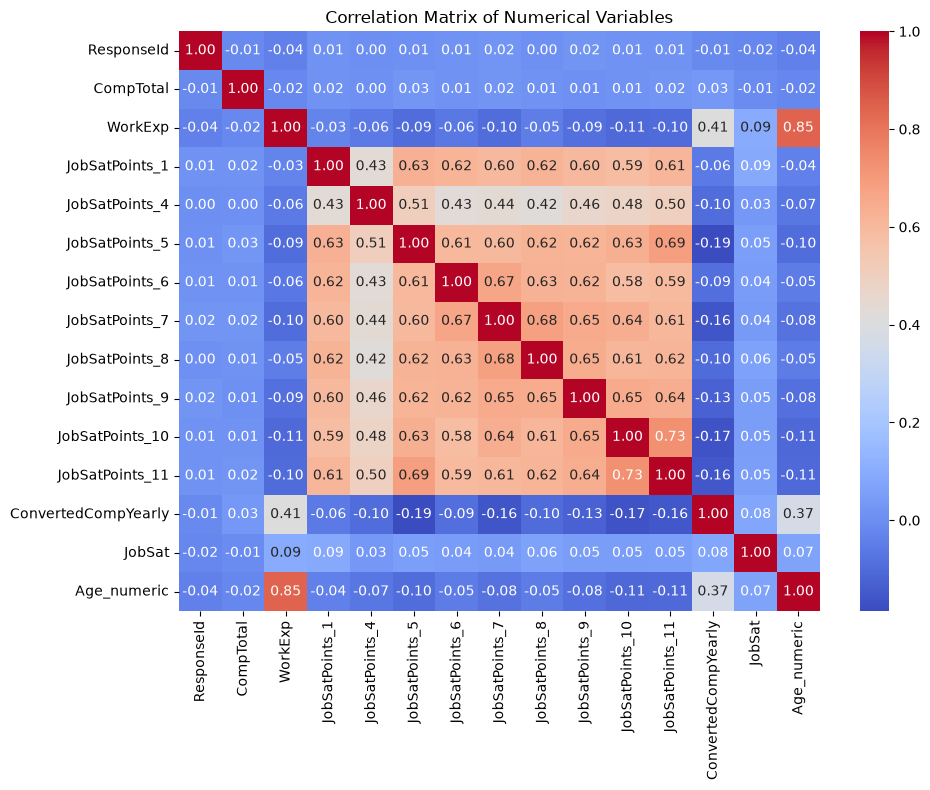

In [45]:
# Visualizing the correlation matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
